# 🏡 Pakistan House Price Prediction - End-to-End Machine Learning Pipeline
**Dataset**: `house_price_pakistan.csv`  
**Problem Type**: Supervised Regression  
**Framework**: Scikit-Learn, Pandas, NumPy, Matplotlib, Seaborn, Joblib  

---

## 📌 Problem Statement
Real estate agents, buyers, and sellers in Pakistan often face uncertainty regarding the fair market value of residential properties. Valuations are frequently based on subjective guesswork or broker estimates, resulting in discrepancies where buyers may overpay or sellers underprice their homes.

### 🎯 Objective
Build a predictive machine learning model to estimate the fair market price of a house (`price_lakh_pkr`) based on key physical, spatial, and geographic attributes (city, location, size in Marla/Sqft, bedrooms, bathrooms, stories, age, road access, garage, gas, furnishing, and school proximity).

### 📋 7-Step Solution Approach:
1. **Exploratory Data Analysis (EDA)**: Understand distribution, relationships, city/location price drivers, and correlation.
2. **Data Preprocessing**: Drop irrelevant identifiers (`property_id`), encode categorical variables (`city`, `location`) with `OneHotEncoder`.
3. **Train-Test Split**: Divide data into 80% training and 20% testing sets to assess generalization on unseen properties.
4. **Model Training**: Train baseline **Linear Regression** and advanced **Random Forest Regressor**.
5. **Model Evaluation**: Evaluate performance using **MAE**, **RMSE**, and **R² Score**, inspect residuals and feature importances.
6. **Save the Model**: Persist the trained pipeline using `joblib` into a `.pkl` file for production deployment.
7. **Streamlit Web Application**: Deploy an interactive web app (`app.py`) for live real-time valuation.


---
## 🔍 Step 1: Exploratory Data Analysis (EDA)
Let us first inspect the dataset structure, summary statistics, missing values, and visual distributions of key property features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual style setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load dataset
df = pd.read_csv('house_price_pakistan.csv')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Shape: 1200 rows, 15 columns


,property_id,city,location,area_marla,area_sqft,bedrooms,bathrooms,stories,age_years,main_road_access,garage,gas_available,furnished,nearby_school_km,price_lakh_pkr
0,PROP-00001,Karachi,Bahria Town,5,1146,1,1,1.0,18,1,0,1,0,0.23,115.4
1,PROP-00002,Faisalabad,Model Town,5,1095,1,1,2.0,24,1,0,1,0,0.52,60.3
2,PROP-00003,Karachi,Gulshan-e-Iqbal,5,1138,1,1,2.5,6,0,0,1,1,5.06,102.4
3,PROP-00004,Islamabad,DHA,3,632,2,2,2.5,3,1,0,1,1,0.31,118.9
4,PROP-00005,Rawalpindi,DHA,5,1174,2,2,2.5,7,1,1,1,1,2.79,152.5


In [2]:
# Check data types and null values
print("=== Column Info & Missing Values ===")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())


=== Column Info & Missing Values ===
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       1200 non-null   str    
 1   city              1200 non-null   str    
 2   location          1200 non-null   str    
 3   area_marla        1200 non-null   int64  
 4   area_sqft         1200 non-null   int64  
 5   bedrooms          1200 non-null   int64  
 6   bathrooms         1200 non-null   int64  
 7   stories           1200 non-null   float64
 8   age_years         1200 non-null   int64  
 9   main_road_access  1200 non-null   int64  
 10  garage            1200 non-null   int64  
 11  gas_available     1200 non-null   int64  
 12  furnished         1200 non-null   int64  
 13  nearby_school_km  1200 non-null   float64
 14  price_lakh_pkr    1200 non-null   float64
dtypes: float64(3), int64(9), str(3)
memory usage: 172.1 KB
None

Mi

In [3]:
# Summary statistics for numerical columns
df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]


,count,mean,std,min,25%,50%,75%,max
area_marla,1200.0,7.489167,3.975095,3.0,5.00,7.00,10.00,20.00
area_sqft,1200.0,1683.236667,893.805736,625.0,1105.00,1545.50,2243.00,4549.00
bedrooms,1200.0,3.070000,1.788696,1.0,2.00,3.00,4.00,9.00
bathrooms,1200.0,2.674167,1.728339,1.0,1.00,2.00,4.00,9.00
stories,1200.0,1.677500,0.536563,1.0,1.00,2.00,2.00,2.50
age_years,1200.0,16.650000,9.892373,0.0,8.00,17.00,25.00,34.00
main_road_access,1200.0,0.707500,0.455100,0.0,0.00,1.00,1.00,1.00
garage,1200.0,0.674167,0.468881,0.0,0.00,1.00,1.00,1.00
gas_available,1200.0,0.905000,0.293337,0.0,1.00,1.00,1.00,1.00
furnished,1200.0,0.287500,0.452785,0.0,0.00,0.00,1.00,1.00


### 📊 Visualizing Price Distribution
Let's observe the distribution of the target variable `price_lakh_pkr` across Pakistan properties.


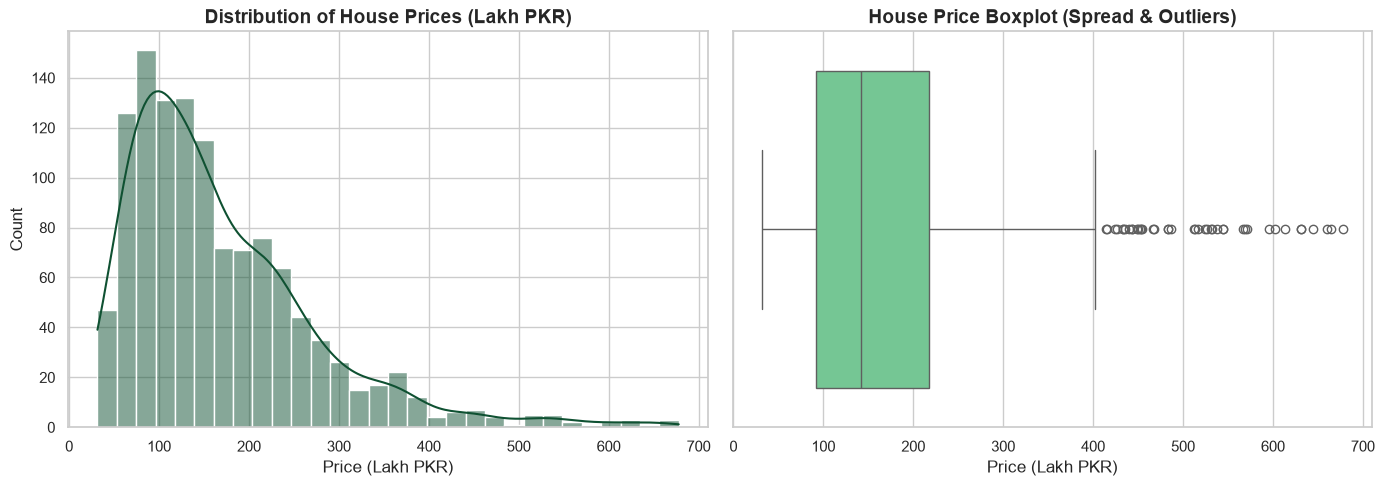

Mean Price:   168.92 Lakh PKR
Median Price: 141.80 Lakh PKR
Min Price:    31.50 Lakh PKR
Max Price:    677.90 Lakh PKR


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['price_lakh_pkr'], kde=True, color='#0f5132', ax=axes[0], bins=30)
axes[0].set_title('Distribution of House Prices (Lakh PKR)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (Lakh PKR)')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(x=df['price_lakh_pkr'], color='#68d391', ax=axes[1])
axes[1].set_title('House Price Boxplot (Spread & Outliers)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price (Lakh PKR)')

plt.tight_layout()
plt.show()

print(f"Mean Price:   {df['price_lakh_pkr'].mean():.2f} Lakh PKR")
print(f"Median Price: {df['price_lakh_pkr'].median():.2f} Lakh PKR")
print(f"Min Price:    {df['price_lakh_pkr'].min():.2f} Lakh PKR")
print(f"Max Price:    {df['price_lakh_pkr'].max():.2f} Lakh PKR")


### 🏙️ Price Distribution Across Major Cities
How do real estate values compare between Islamabad, Karachi, Lahore, Rawalpindi, and Faisalabad?


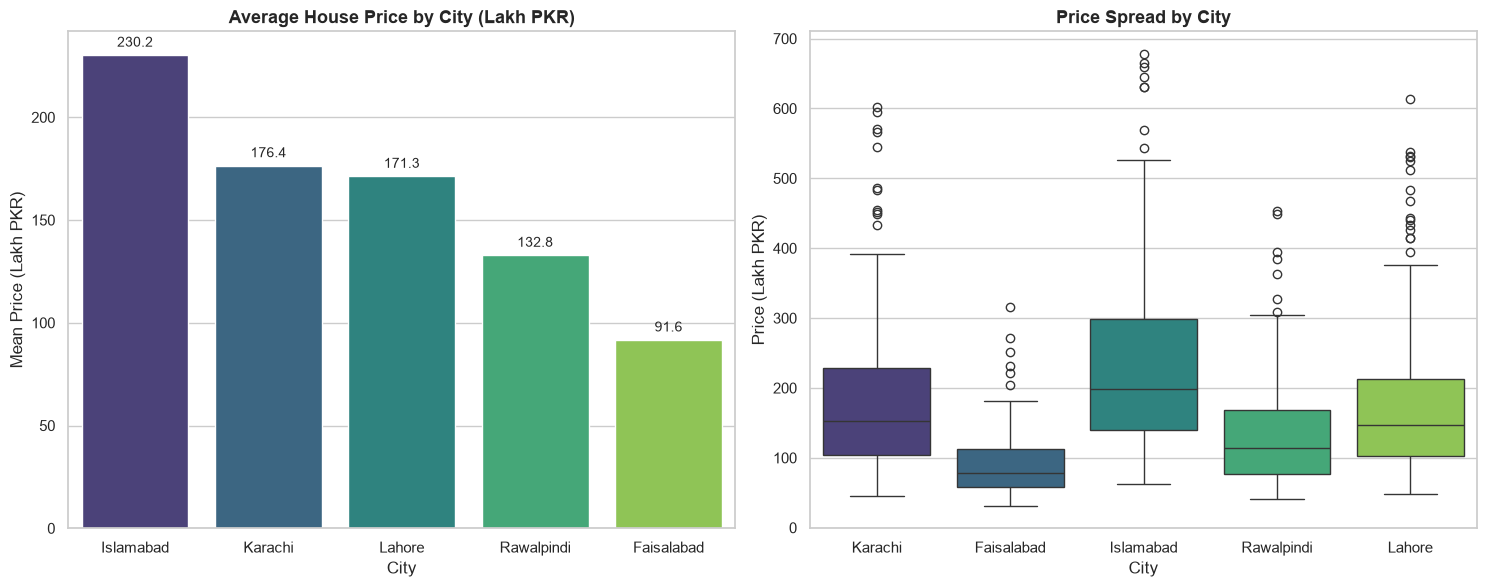

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Average Price by City
city_avg = df.groupby('city')['price_lakh_pkr'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=city_avg, x='city', y='price_lakh_pkr', palette='viridis', ax=axes[0])
axes[0].set_title('Average House Price by City (Lakh PKR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Mean Price (Lakh PKR)')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

# Boxplot by City
sns.boxplot(data=df, x='city', y='price_lakh_pkr', palette='viridis', ax=axes[1])
axes[1].set_title('Price Spread by City', fontsize=13, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Price (Lakh PKR)')

plt.tight_layout()
plt.show()


### 📐 Relationship Between Area (Marla / Sqft) and Price
Area is one of the strongest determinants of property valuation. Let's analyze the relationship with city breakdown.


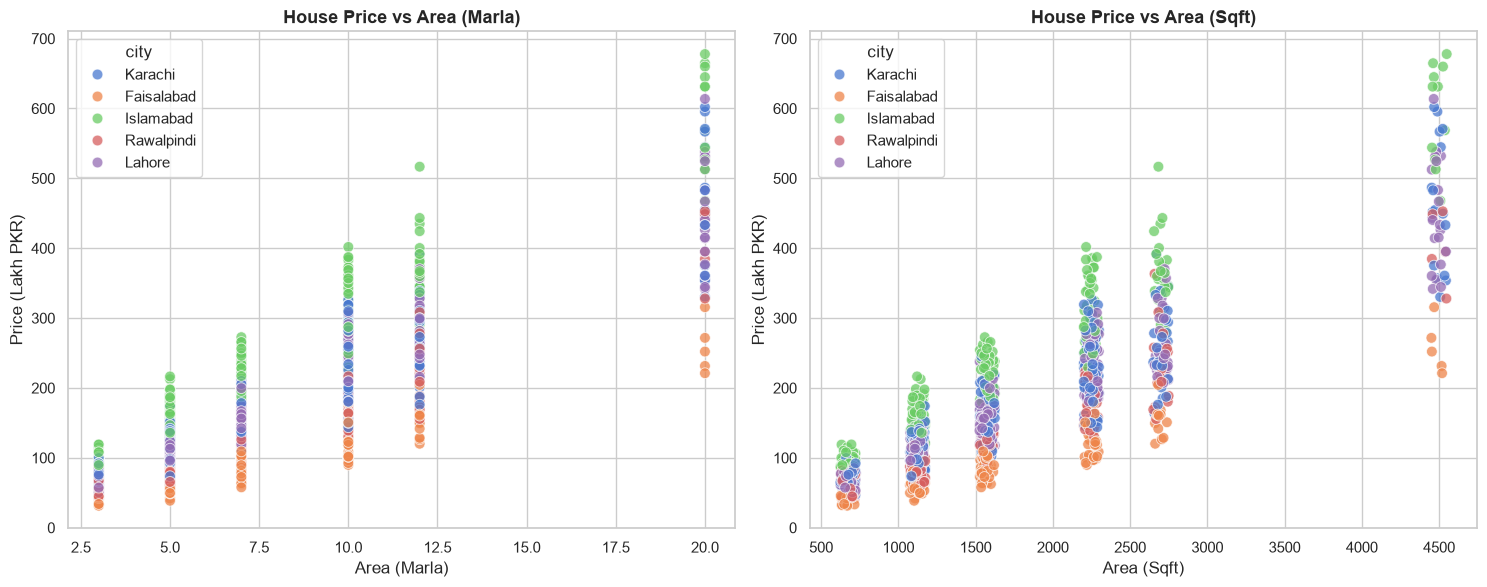

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Area in Marla vs Price
sns.scatterplot(data=df, x='area_marla', y='price_lakh_pkr', hue='city', alpha=0.75, s=60, ax=axes[0])
axes[0].set_title('House Price vs Area (Marla)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Area (Marla)')
axes[0].set_ylabel('Price (Lakh PKR)')

# Area in Sqft vs Price
sns.scatterplot(data=df, x='area_sqft', y='price_lakh_pkr', hue='city', alpha=0.75, s=60, ax=axes[1])
axes[1].set_title('House Price vs Area (Sqft)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Area (Sqft)')
axes[1].set_ylabel('Price (Lakh PKR)')

plt.tight_layout()
plt.show()


### 🛠️ Impact of Amenities & Property Age
Let's see how gas availability, garage, main road access, and furnishing status affect the average property price.


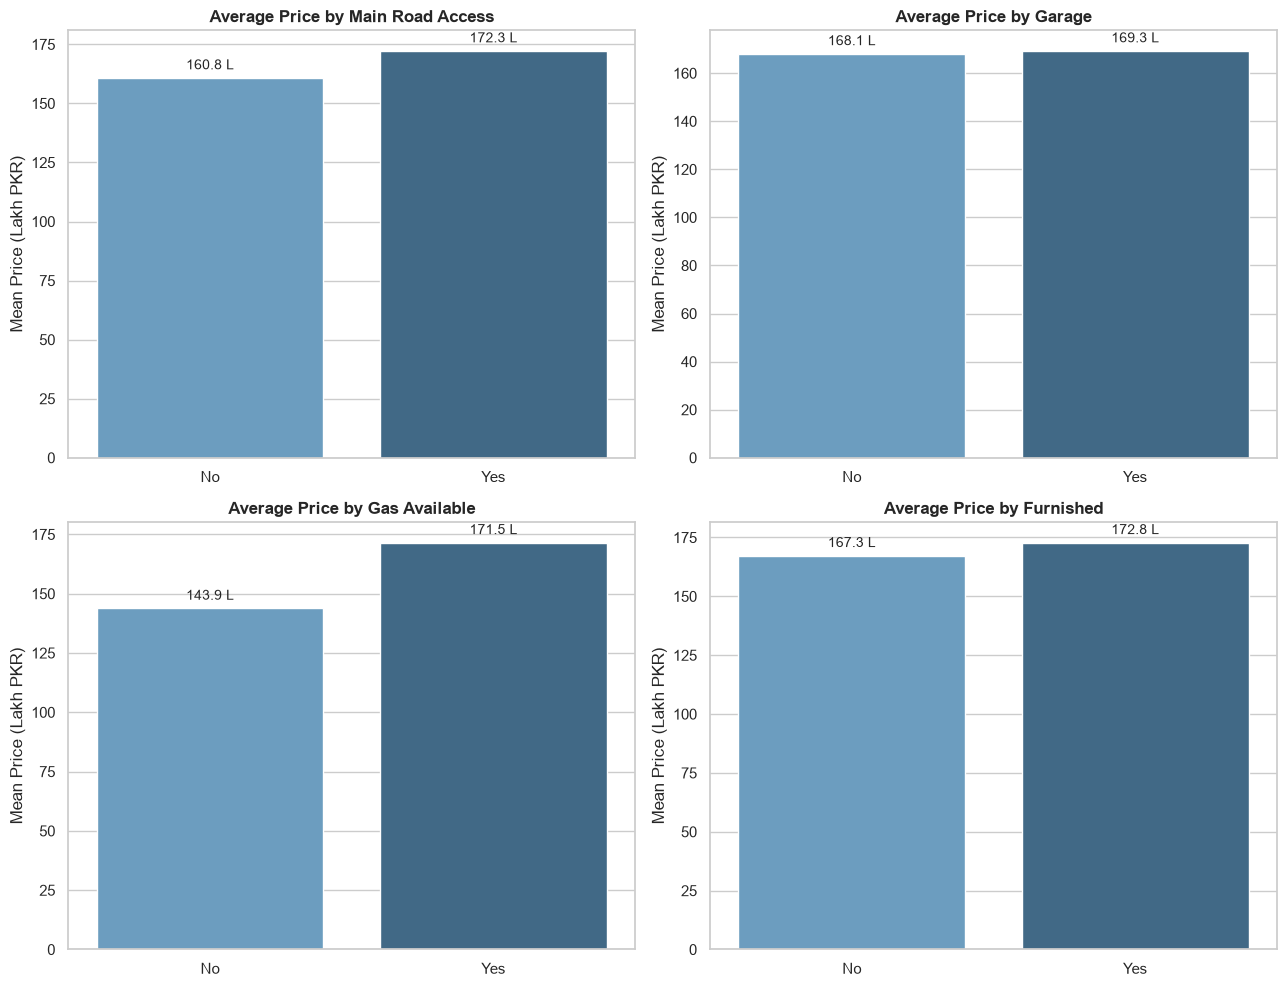

In [7]:
amenities = ['main_road_access', 'garage', 'gas_available', 'furnished']
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for idx, col in enumerate(amenities):
    ax = axes[idx // 2, idx % 2]
    avg_price = df.groupby(col)['price_lakh_pkr'].mean().reset_index()
    avg_price[col] = avg_price[col].map({0: 'No', 1: 'Yes'})
    sns.barplot(data=avg_price, x=col, y='price_lakh_pkr', palette='Blues_d', ax=ax)
    ax.set_title(f'Average Price by {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Price (Lakh PKR)')
    ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f} L", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()


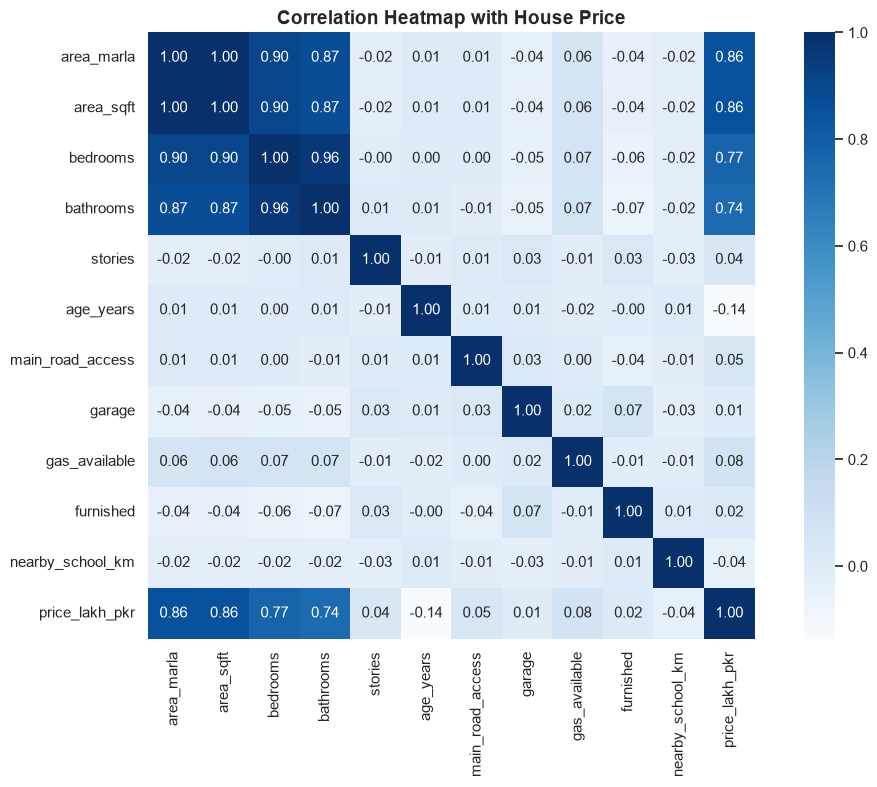


Correlation with Price (Lakh PKR):
price_lakh_pkr      1.000000
area_sqft           0.857199
area_marla          0.857167
bedrooms            0.770262
bathrooms           0.743354
gas_available       0.077004
main_road_access    0.049288
stories             0.038852
furnished           0.023629
garage              0.005284
nearby_school_km   -0.035004
age_years          -0.136120
Name: price_lakh_pkr, dtype: float64


In [8]:
# Correlation Matrix of Numerical Features
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True)
plt.title('Correlation Heatmap with House Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Price (Lakh PKR):")
print(corr['price_lakh_pkr'].sort_values(ascending=False))


---
## ⚙️ Step 2: Data Preprocessing
In accordance with the project guidelines:
1. **Drop `property_id`**: It is an arbitrary identifier and has no causal relation to market value.
2. **Feature Separation**: Separate features matrix $X$ and continuous target vector $y$ (`price_lakh_pkr`).
3. **OneHotEncoding**: Convert categorical features (`city`, `location`) into numerical dummy columns using `OneHotEncoder` via Scikit-Learn `ColumnTransformer`.


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Separate X and y
X = df.drop(columns=['property_id', 'price_lakh_pkr'])
y = df['price_lakh_pkr']

categorical_cols = ['city', 'location']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

print(f"Features count: {X.shape[1]}")
print(f"Categorical features: {categorical_cols}")
print(f"Numerical features:   {numerical_cols}")

# Create ColumnTransformer with OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

print("\nPreprocessor configured successfully.")


Features count: 13
Categorical features: ['city', 'location']
Numerical features:   ['area_marla', 'area_sqft', 'bedrooms', 'bathrooms', 'stories', 'age_years', 'main_road_access', 'garage', 'gas_available', 'furnished', 'nearby_school_km']

Preprocessor configured successfully.


---
## ✂️ Step 3: Train-Test Split (80% Train, 20% Test)
We split the data using an 80/20 ratio with `random_state=42` to evaluate generalization on unseen houses.


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Total instances: {len(X)}")
print(f"Training set:    {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set:     {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")


Total instances: 1200
Training set:    960 samples (80.0%)
Testing set:     240 samples (20.0%)


---
## 🤖 Step 4: Model Training
We build end-to-end Scikit-Learn pipelines for:
1. **Linear Regression** (simple baseline, interpretable)
2. **Random Forest Regressor** (ensemble method capturing non-linear feature interactions)


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
print("✓ Linear Regression trained successfully.")

# 2. Random Forest Regressor Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=16,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)
print("✓ Random Forest Regressor trained successfully.")


✓ Linear Regression trained successfully.


✓ Random Forest Regressor trained successfully.


---
## 📈 Step 5: Model Evaluation
We evaluate both models using:
- **MAE (Mean Absolute Error)**: Average magnitude of prediction errors in Lakh PKR.
- **RMSE (Root Mean Squared Error)**: Penalizes larger deviations more heavily.
- **R² Score (Coefficient of Determination)**: Proportion of variance explained (1.0 = perfect fit).


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred_lr_train = lr_pipeline.predict(X_train)
y_pred_lr_test = lr_pipeline.predict(X_test)

y_pred_rf_train = rf_pipeline.predict(X_train)
y_pred_rf_test = rf_pipeline.predict(X_test)

results = [
    {
        'Model': 'Linear Regression',
        'Train MAE': mean_absolute_error(y_train, y_pred_lr_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_lr_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr_test)),
        'Train R²': r2_score(y_train, y_pred_lr_train),
        'Test R²': r2_score(y_test, y_pred_lr_test)
    },
    {
        'Model': 'Random Forest Regressor',
        'Train MAE': mean_absolute_error(y_train, y_pred_rf_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_rf_test),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf_test)),
        'Train R²': r2_score(y_train, y_pred_rf_train),
        'Test R²': r2_score(y_test, y_pred_rf_test)
    }
]

comparison_df = pd.DataFrame(results).round(3)
comparison_df


,Model,Train MAE,Test MAE,Test RMSE,Train R²,Test R²
0,Linear Regression,18.813,20.509,30.326,0.934,0.924
1,Random Forest Regressor,7.749,18.064,29.753,0.987,0.927


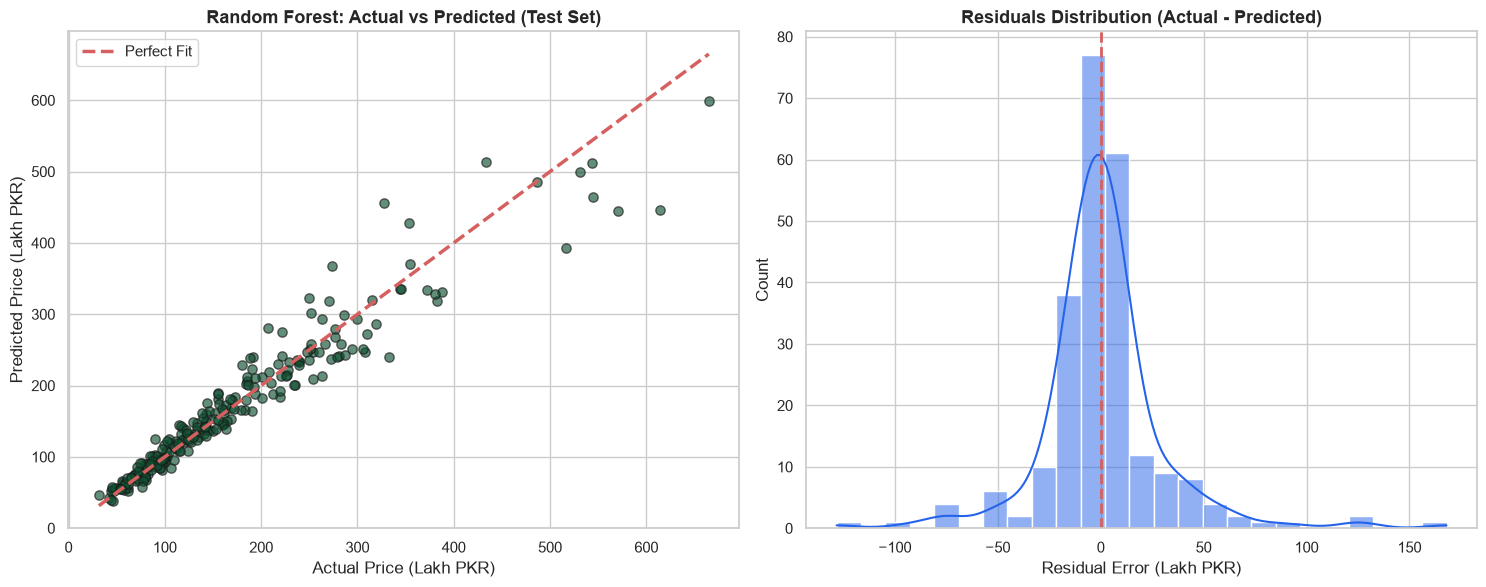

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted for Random Forest
axes[0].scatter(y_test, y_pred_rf_test, color='#0f5132', alpha=0.65, edgecolors='k', s=45)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Perfect Fit')
axes[0].set_title('Random Forest: Actual vs Predicted (Test Set)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Price (Lakh PKR)')
axes[0].set_ylabel('Predicted Price (Lakh PKR)')
axes[0].legend()

# Residual Distribution
residuals_rf = y_test - y_pred_rf_test
sns.histplot(residuals_rf, kde=True, color='#2563eb', ax=axes[1], bins=25)
axes[1].axvline(0, color='r', linestyle='--', lw=2)
axes[1].set_title('Residuals Distribution (Actual - Predicted)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual Error (Lakh PKR)')

plt.tight_layout()
plt.show()


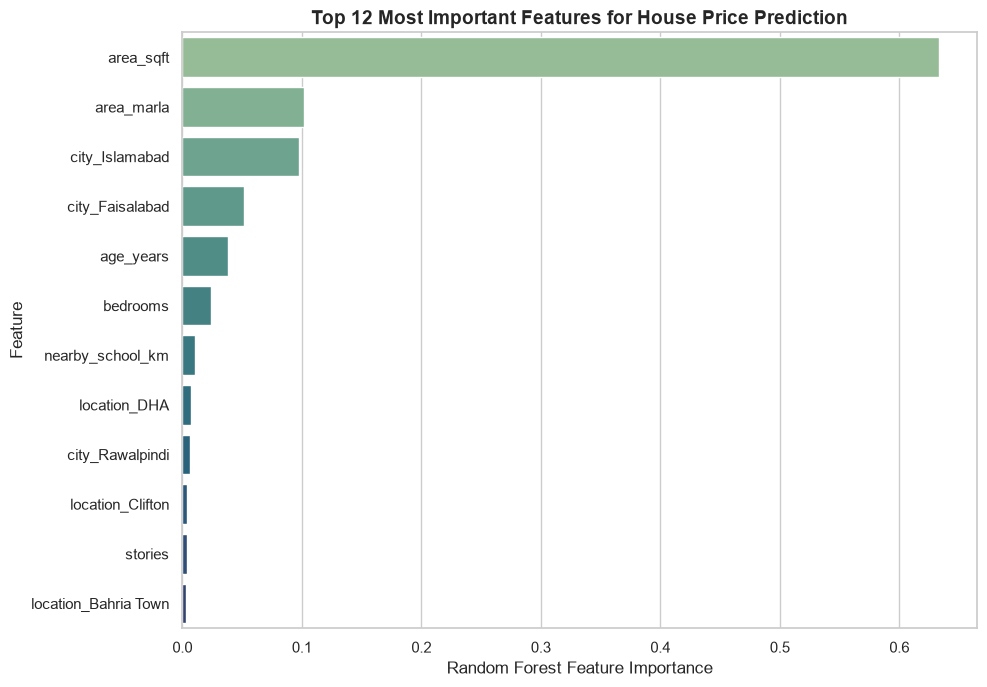

,Feature,Importance
23,area_sqft,0.633330
22,area_marla,0.101608
1,city_Islamabad,0.097881
0,city_Faisalabad,0.051637
27,age_years,0.038512
24,bedrooms,0.024244
32,nearby_school_km,0.010501
9,location_DHA,0.007113
4,city_Rawalpindi,0.006158
8,location_Clifton,0.003804


In [14]:
# Extract Feature Importances from Random Forest
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features = cat_feature_names + numerical_cols
rf_importances = rf_pipeline.named_steps['regressor'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_df.head(12), x='Importance', y='Feature', palette='crest')
plt.title('Top 12 Most Important Features for House Price Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Random Forest Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

feat_imp_df.head(12)


---
## 💾 Step 6: Save the Trained Model
We save the trained Scikit-Learn pipeline to `house_price_model.pkl` using `joblib`. Because the preprocessor is bundled with the model, raw user inputs can be passed directly to `model.predict()`.


In [15]:
import joblib

# Save model pipeline
model_filename = 'house_price_model.pkl'
joblib.dump(rf_pipeline, model_filename)
print(f"✓ Model pipeline saved successfully to '{model_filename}'")

# Test loading the model and making an inference
loaded_model = joblib.load(model_filename)

sample_house = pd.DataFrame([{
    'city': 'Lahore',
    'location': 'DHA',
    'area_marla': 10,
    'area_sqft': 2250,
    'bedrooms': 4,
    'bathrooms': 4,
    'stories': 2.0,
    'age_years': 3,
    'main_road_access': 1,
    'garage': 1,
    'gas_available': 1,
    'furnished': 1,
    'nearby_school_km': 0.5
}])

predicted_price = loaded_model.predict(sample_house)[0]
print(f"Sample House Valuation:")
print(f"City: Lahore | Location: DHA | Area: 10 Marla (2250 Sqft)")
print(f"Predicted Price: {predicted_price:.2f} Lakh PKR (~{predicted_price/100:.2f} Crore PKR)")


✓ Model pipeline saved successfully to 'house_price_model.pkl'
Sample House Valuation:
City: Lahore | Location: DHA | Area: 10 Marla (2250 Sqft)
Predicted Price: 268.53 Lakh PKR (~2.69 Crore PKR)


---
## 🚀 Step 7: Streamlit Web Application Integration
The saved `house_price_model.pkl` is loaded by our interactive Streamlit application (`app.py`).

### Key Features of `app.py`:
- 🏡 **Interactive Price Predictor**: Dynamic sliders, city-location cascading dropdowns, unit toggles (Marla/Sqft/Kanal, Lakh/Crore).
- 📊 **Market EDA Dashboard**: Real-time charts, city-wise pricing trends, amenities value impact.
- 🧠 **Model Diagnostics**: Accuracy metrics (MAE, RMSE, R²), feature importance breakdown.
- 🇵🇰 **Pakistan Real Estate Theme**: Styled with emerald green, clean typography, responsive layout, and fair price insights.

To run the application:
```bash
streamlit run app.py
```
